# Detection: RetinaNet

* detection: bbox & label 예측
* detection을 위한 RetinaNet 직접 구현 및 S2TLD(4cls) 데이터로 확인

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

import torch
print("visible:", os.environ["CUDA_VISIBLE_DEVICES"])
print("cuda count:", torch.cuda.device_count())   # 1이어야 정상
print("current:", torch.cuda.current_device())    # 0
print("name:", torch.cuda.get_device_name(0))

visible: 6
cuda count: 1
current: 0
name: NVIDIA B200


In [ ]:
# library
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from collections import Counter
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.patches as patches
import seaborn as sns

DEVICE= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1. Backbone: ResNet

* Resnet: pretrained 
* torchvision model 불러오기

In [ ]:
# ResNet (ImageNet pretrained)
import torchvision.models as tv_models

class ResNet2D(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        base = tv_models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        # imagenet분류 학습 

        self.stem   = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1  # C2: 256ch,  stride 4
        self.layer2 = base.layer2  # C3: 512ch,  stride 8
        self.layer3 = base.layer3  # C4: 1024ch, stride 16
        self.layer4 = base.layer4  # C5: 2048ch, stride 32

    def forward(self, x):
        s  = self.stem(x)
        c2 = self.layer1(s)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5  # P3-P7 FPN은 C3~C5만 사용

### 2. FPN

In [5]:
# FPN (P3-P7)
class FPN2D(nn.Module):
    def __init__(self, out_channel=256):
        super().__init__()
        C = out_channel

        # Lateral: C3, C4, C5 → 256 (1x1 conv)
        self.lat_c3 = nn.Conv2d( 512, C, 1)
        self.lat_c4 = nn.Conv2d(1024, C, 1)
        self.lat_c5 = nn.Conv2d(2048, C, 1)

        # Output conv - aliasing 방지 (3x3)
        self.out_p3 = nn.Conv2d(C, C, 3, padding=1)
        self.out_p4 = nn.Conv2d(C, C, 3, padding=1)
        self.out_p5 = nn.Conv2d(C, C, 3, padding=1)

        # P6: C5에서 stride-2 conv
        self.p6 = nn.Conv2d(2048, C, 3, stride=2, padding=1)
        # P7: P6에서 stride-2 conv
        self.p7 = nn.Sequential(nn.ReLU(), nn.Conv2d(C, C, 3, stride=2, padding=1))

    def forward(self, c3, c4, c5):
        # Top-down pathway
        p5 = self.lat_c5(c5)
        p4 = self.lat_c4(c4) + F.interpolate(p5, size=c4.shape[2:])
        p3 = self.lat_c3(c3) + F.interpolate(p4, size=c3.shape[2:])

        p3 = self.out_p3(p3)
        p4 = self.out_p4(p4)
        p5 = self.out_p5(p5)

        # Bottom-up extension
        p6 = self.p6(c5)
        p7 = self.p7(p6)

        return p3, p4, p5, p6, p7

In [35]:
# FPN: ResNet의 피쳐맵에서 multi scale 특징 추출 
# FPN + ResNet 조합 구현 


class FPN(nn.Module):
    def __init__(self, num_blocks):
        super().__init__()
        # stem layer
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # resnet
        self.layer1 = self._make_layer(64, num_blocks[0], 1)
        self.layer2 = self._make_layer(128, num_blocks[1], 2)
        self.layer3 = self._make_layer(256, num_blocks[2], 2)
        self.layer4 = self._make_layer(512, num_blocks[3], 2)

        # p5에서 p6, p7 생성 
        self.conv6 = nn.Conv2d(2048, 256, 3, stride=2, padding=1)
        self.conv7 = nn.Sequential(
            nn.ReLU(), 
            nn.Conv2d(256, 256, 3, stride=2, padding=1))

        # lateral connection
        self.lateral_1 = nn.Conv2d(2048, 256, 1, stride=1, padding=0)
        self.lateral_2 = nn.Conv2d(1024, 256, 1, stride=1, padding=0)
        self.lateral_3 = nn.Conv2d(512, 256, 1, stride=1, padding=0)

        # Top-down pathway
        # Output conv - aliasing 방지 (3x3)
        self.top_down_0 = nn.Conv2d(256, 256, 3, stride=1, padding=1)
        self.top_down_1 = nn.Conv2d(256, 256, 3, stride=1, padding=1)
        self.top_down_2 = nn.Conv2d(256, 256, 3, stride=1, padding=1)

        # upsampling
        self.upsample_1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.upsample_2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    def _make_layer(self, inner_channels, num_block, stride):
        strides = [stride] + [1] * (num_block-1) # 첫 블록만 stride, 나머지 블록은 1
        layers = []
        for stride in strides:
            layers.append(BottleNeck2D(self.in_channels, inner_channels, stride=stride))
            self.in_channels = inner_channels*BottleNeck2D.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        # feature extraction
        c1 = self.relu(self.bn1(self.conv1(x)))
        c1 = self.maxpool(c1)
        c2 = self.layer1(c1)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)

        # FPN
        p6 = self.conv6(c5)
        p7 = self.conv7(p6)
        p5 = self.top_down_0(self.lateral_1(c5))
        p4 = self.top_down_1(self.upsample_1(p5) + self.lateral_2(c4))
        p3 = self.top_down_2(self.upsample_2(p4) + self.lateral_3(c3)) 

        return p3, p4, p5, p6, p7

# ResNet 50
def FPN50():
    return FPN([3, 4, 6, 3])

# check
if __name__ == "__main__":
    x = torch.randn(1, 3, 640, 640, device=DEVICE)
    model = FPN50().to(DEVICE)
    outputs = model(x)

    for output in outputs:
        print(output.shape)

torch.Size([1, 256, 80, 80])
torch.Size([1, 256, 40, 40])
torch.Size([1, 256, 20, 20])
torch.Size([1, 256, 10, 10])
torch.Size([1, 256, 5, 5])


### 3. Head: Subnet

In [32]:
class SubNet2D(nn.Module):
	def __init__(self, num_anchors, num_cls):
		super().__init__()
		self.convs = nn.ModuleList([
			nn.Sequential(
				nn.Conv2d(256, 256, 3, padding=1),
				nn.ReLU(inplace=True),
			) for _ in range(4)
		])
	     
		self.num_cls = num_cls
		self.num_anchors = num_anchors
		
		self.cls_head = nn.Conv2d(256, num_cls*num_anchors, 1)
		self.reg_head = nn.Conv2d(256, 4*num_anchors, 1)
		# 확률 - 좌표 출력을 위해서 activation 없이 raw output 출력
		
		nn.init.constant_(self.cls_head.bias, -4.6) # cls_head bias -4.6으로 초기화 / 모든 앵커의 예측확률 1%로 설정
		
	def forward(self, features):
		# features = [p3, p4, p5, p6, p7], 같은 가중치를 공유하는 모든 레벨에 대해 동일한 연산 수행 
		
		cls_outputs = []
		reg_outputs = []
		
		for feature in features:
			x = feature			
			for conv in self.convs: 
				x = conv(x)  
				# 하나의 가중치를 각각 다른 입력에 적용 - 객체 크기와 무관하게 객체를 찾는 것을 학습
				# 가중치 자체는 해상도에 영향을 받지 않음  
			cls = self.cls_head(x) 					# (B, num_cls*num_anchors, H, W)
			reg = self.reg_head(x) 					# (B, 4*num_anchors, H, W)
			
			# permute / reshape

			B = x.shape[0]	
			H, W = cls.shape[2], cls.shape[3]
			cls = cls.permute(0, 2, 3, 1).reshape(B, H, W, self.num_anchors, self.num_cls).reshape(B, -1, self.num_cls) #(B, H, W, num_cls*num_anchors) -> (B, H*W*num_anchors, num_cls)
			reg = reg.permute(0, 2, 3, 1).reshape(B, H, W, self.num_anchors, 4).reshape(B, -1, 4) #(B, H, W, 4*num_anchors) -> (B, H*W*num_anchors, 4)
			
			# list 
			cls_outputs.append(cls)
			reg_outputs.append(reg)			
		
		# 한 번에 다 합치기: concat 
		cls_outputs = torch.cat(cls_outputs, dim=1) # (1, H*W*num_anchors(모든 레벨 합산), num_cls) 이어붙이기
		reg_outputs = torch.cat(reg_outputs, dim=1) # (1, H*W*num_anchors(모든 레벨 합산), 4)
		
		return cls_outputs, reg_outputs
		# cls_outputs: (1, A(H3W3 + H4W4 + H5W5 + H6W6 + H7W7), num_cls)
		# reg_outputs: (1, A(H3W3 + H4W4 + H5W5 + H6W6 + H7W7), 4)

# test
x = torch.randn(1, 3, 640, 640, device=DEVICE)
fpn = FPN50().to(DEVICE)
features = fpn(x)

if __name__ == "__main__":
	subnet = SubNet2D(12, 20).to(DEVICE)
	cls_outputs, reg_outputs = subnet(features)

	print(cls_outputs.shape)
	print(reg_outputs.shape)

torch.Size([1, 102300, 20])
torch.Size([1, 102300, 4])


### 4. Anchor Generator

In [ ]:
# Anchor Generator (P3-P7, strides 8~128)
# 이건 모든 cell에 대해 앵커 12개 생성 
class AnchorGenerator2D(nn.Module):
    def __init__(self,
        strides       = [8, 16, 32, 64, 128],
        sizes         = [8, 16, 32, 64, 128],
        scales        = [0.5, 1, 2**(1/3), 2**(2/3)],
        aspect_ratios = [0.5, 1.0, 2.0]
    ):
        super().__init__()
        self.strides = strides

        for i, size in enumerate(sizes):
            wh = []
            for scale in scales:
                for ratio in aspect_ratios:
                    area = (size * scale) ** 2
                    w = np.sqrt(area * ratio)
                    h = np.sqrt(area / ratio)
                    wh.append([w, h])
            self.register_buffer(f"cell_anchor_{i}", torch.tensor(wh, dtype=torch.float32))

    def forward(self, features):
        all_anchors = []

        # feature map의 H, W 격자 위치마다 anchor 배치 
        for i, (feature, stride) in enumerate(zip(features, self.strides)):
            B, C, H, W = feature.shape
            device = feature.device
            wh_list = getattr(self, f"cell_anchor_{i}").to(device)

            gy = torch.arange(H, dtype=torch.float32, device=device) * stride
            gx = torch.arange(W, dtype=torch.float32, device=device) * stride
            cy, cx = torch.meshgrid(gy, gx, indexing='ij')

            cy = cy.reshape(-1, 1)
            cx = cx.reshape(-1, 1)
            w  = wh_list[:, 0].reshape(1, -1)
            h  = wh_list[:, 1].reshape(1, -1)

            anchors = torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=2)
            all_anchors.append(anchors.reshape(-1, 4))

        return torch.cat(all_anchors, dim=0)
# P3(80x80):76800, P4(40x40):19200, P5(20x20):4800, P6(10x10):1200, P7(5x5):300 -> 합계 102300

In [ ]:
# debugging
sizes        = [8, 16, 32, 64, 128]  # 레벨 별 기본 크기 
scales       = [1, 2**(1/3), 2**(2/3)]  # 기본 크기에 곱하는 배율
aspect_ratios = [0.5, 1.0, 2.0]         # 가로, 세로 비율 

base_anchors = []
for size in sizes:
    wh = []
    for scale in scales:
        for ratio in aspect_ratios:
            area = (size * scale)**2
            w = np.sqrt(area * ratio)
            h = np.sqrt(area / ratio)
            wh.append([w, h])
    base_anchors.append(torch.tensor(wh, dtype=torch.float32))

for i, anchors in enumerate(base_anchors):
    print(f"p{i+2} 레벨: shape={anchors.shape}")
    print(anchors)
    print()

p2 레벨: shape=torch.Size([9, 2])
tensor([[22.6274, 45.2548],
        [32.0000, 32.0000],
        [45.2548, 22.6274],
        [28.5088, 57.0175],
        [40.3175, 40.3175],
        [57.0175, 28.5088],
        [35.9188, 71.8376],
        [50.7968, 50.7968],
        [71.8376, 35.9188]])

p3 레벨: shape=torch.Size([9, 2])
tensor([[ 45.2548,  90.5097],
        [ 64.0000,  64.0000],
        [ 90.5097,  45.2548],
        [ 57.0175, 114.0350],
        [ 80.6349,  80.6349],
        [114.0350,  57.0175],
        [ 71.8376, 143.6751],
        [101.5937, 101.5937],
        [143.6751,  71.8376]])

p4 레벨: shape=torch.Size([9, 2])
tensor([[ 90.5097, 181.0193],
        [128.0000, 128.0000],
        [181.0193,  90.5097],
        [114.0350, 228.0701],
        [161.2699, 161.2699],
        [228.0701, 114.0350],
        [143.6751, 287.3503],
        [203.1873, 203.1873],
        [287.3503, 143.6751]])

p5 레벨: shape=torch.Size([9, 2])
tensor([[181.0193, 362.0387],
        [256.0000, 256.0000],
        [362.0

In [ ]:
# debugging

# 2*3 크기의 feature map에서 앵커 생성
# gx = [[0, 0, 0], [1, 1, 1]] 
# gy = [[0, 1, 2], [0, 1, 2]]
# 즉, [[0,0],[0,1], [0,2], [1,0], [1,1], [1,2]]

stride = 8                  # feature map이 원본 이미지 좌표에서 몇 번째 위치인지를 계산
H, W = 2, 3
anchor = base_anchors[0]

gy = torch.arange(H, dtype=torch.float32) * stride
gx = torch.arange(W, dtype=torch.float32) * stride
cy, cx = torch.meshgrid(gy, gx, indexing='ij') # (H, W)
print(f"w,h: {anchor}, \nshape: {anchor.shape}")
print(f"\ngy: {gy}, \ngx: {gx}, \ncy: {cy}, \ncx: {cx}")

cy = cy.reshape(-1, 1)              # (H*W, 1)
cx = cx.reshape(-1, 1)              # (H*W, 1)

w = anchor[:, 0].reshape(1, -1)     # (1, 9)
h = anchor[:, 1].reshape(1, -1)     # (1, 9)
print(f"\ncy: {cy}, \ncx: {cx}, \nw: {w}, \nh: {h}")

# torch broad casting: 모든 조합을 계산! 파이토치 특징 기능
xmin = cx - w/2
ymin = cy - h/2
xmax = cx + w/2
ymax = cy + h/2
print(f"\nxmin: {xmin}, \nymin: {ymin}, \nxmax: {xmax}, \nymax: {ymax}")

# anchor 
anchors = torch.stack([xmin, ymin, xmax, ymax], dim=2)  # (H*W, 9, 4)
anchors = anchors.reshape(-1, 4)                         # (H*W*9, 4)
print(f"\nanchors: {anchors}, \nshape: {anchors.shape}")

all_anchors = []
all_anchors.append(anchors)

w,h: tensor([[22.6274, 45.2548],
        [32.0000, 32.0000],
        [45.2548, 22.6274],
        [28.5088, 57.0175],
        [40.3175, 40.3175],
        [57.0175, 28.5088],
        [35.9188, 71.8376],
        [50.7968, 50.7968],
        [71.8376, 35.9188]]), 
shape: torch.Size([9, 2])

gy: tensor([0., 8.]), 
gx: tensor([ 0.,  8., 16.]), 
cy: tensor([[0., 0., 0.],
        [8., 8., 8.]]), 
cx: tensor([[ 0.,  8., 16.],
        [ 0.,  8., 16.]])

cy: tensor([[0.],
        [0.],
        [0.],
        [8.],
        [8.],
        [8.]]), 
cx: tensor([[ 0.],
        [ 8.],
        [16.],
        [ 0.],
        [ 8.],
        [16.]]), 
w: tensor([[22.6274, 32.0000, 45.2548, 28.5088, 40.3175, 57.0175, 35.9188, 50.7968,
         71.8376]]), 
h: tensor([[45.2548, 32.0000, 22.6274, 57.0175, 40.3175, 28.5088, 71.8376, 50.7968,
         35.9188]])

xmin: tensor([[-11.3137, -16.0000, -22.6274, -14.2544, -20.1587, -28.5088, -17.9594,
         -25.3984, -35.9188],
        [ -3.3137,  -8.0000, -14.6274, 

### 5. GT Matching

In [8]:
def xyxy_to_cxcywh(boxes):
    x1, y1, x2, y2 = boxes.unbind(-1)
    w = (x2 - x1).clamp(min=1e-6)
    h = (y2 - y1).clamp(min=1e-6)
    cx = x1 + 0.5 * w
    cy = y1 + 0.5 * h
    return torch.stack([cx, cy, w, h], dim=-1)

def cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)


class BoxCoder2D:
    # encoding + decoding / 서로가 역연산 관계
    # encode: 학습용 gt offset 정답 만들기 - anchor + mached_gt > reg_target
    # decoder: 추론 시의 예측 box 복원 - anchor + reg_pred > bbox 좌표
     
    def encode(self, anchors_xyxy, gt_xyxy): 
        # 모두  cxcywh 형식으로 변환
        anchors = xyxy_to_cxcywh(anchors_xyxy)
        gt = xyxy_to_cxcywh(gt_xyxy)
        
        # offset 계산 - 정규화 포함 
        gcx, gcy, gcw, gch = gt.unbind(-1)
        acx, acy, aw, ah = anchors.unbind(-1)

        dx = (gcx - acx) / aw
        dy = (gcy - acy) / ah
        dw = torch.log(gcw / aw)
        dh = torch.log(gch / ah)

        reg_target = torch.stack([dx, dy, dw, dh], dim=-1)
        return reg_target
    
    def decode(self, anchors_xyxy, reg_target):
        # 모두 cxcywh 형식으로 변환
        anchors = xyxy_to_cxcywh(anchors_xyxy)
        acx, acy, aw, ah = anchors.unbind(-1)
        dx, dy, dw, dh = reg_target.unbind(-1)

        dw = dw.clamp(min=-4.0, max=4.0)   # exp(4) ≈ 55배 제한
        dh = dh.clamp(min=-4.0, max=4.0)  
        dx = dx.clamp(min=-4.0, max=4.0)  
        dy = dy.clamp(min=-4.0, max=4.0)  

        cx = acx + dx * aw
        cy = acy + dy * ah
        w  = aw * torch.exp(dw)
        h  = ah * torch.exp(dh)

        pred_boxes = torch.stack([cx, cy, w, h], dim=-1)
        return cxcywh_to_xyxy(pred_boxes)  

In [ ]:
# GT matcher
from torchvision.ops import box_iou

class Matcher:
    def __init__(self, pos_thr=0.35, neg_thr=0.25):
        self.pos_thr   = pos_thr
        self.neg_thr   = neg_thr
        self.box_coder = BoxCoder2D()

    def forward(self, anchors, gt_boxes, gt_labels):
        N = anchors.shape[0]

        # 배열 초기화 
        if gt_boxes.numel() == 0:
            cls_target = torch.zeros(N, dtype=torch.long, device=anchors.device)
            reg_target = torch.zeros(N, 4, device=anchors.device)
            max_iou    = torch.zeros(N, device=anchors.device)
            return cls_target, reg_target, max_iou

        iou = box_iou(anchors, gt_boxes)    # 출력 행렬 크기 (N_anchor, N_gt)
        max_iou, gt_idx = iou.max(dim=1)

        cls_target = gt_labels[gt_idx]
        cls_target[(max_iou >= self.neg_thr) & (max_iou < self.pos_thr)] = -1
        cls_target[max_iou < self.neg_thr] = 0

        reg_target = torch.zeros(N, 4, device=anchors.device)
        pos = max_iou >= self.pos_thr
        if pos.any():
            reg_target[pos] = self.box_coder.encode(anchors[pos], gt_boxes[gt_idx[pos]])

        return cls_target, reg_target, max_iou

In [ ]:
# debugging 
# anchor 
anchors = torch.tensor([
    [260., 210., 325., 340.],  # GT0(chair)과 많이 겹침
    [160., 260., 255., 375.],  # GT1(chair)과 많이 겹침
    [0.,   0.,  50.,  50.],    # 아무것도 안 겹침
    [240., 190., 300., 300.],  # GT2(chair)과 겹침
    [400., 400., 500., 500.],  # 아무것도 안 겹침
], dtype=torch.float32)

# GT 
xml_path = f"{ANNOTATION_ROOT}/000005.xml"
gt_boxes, gt_labels = parse_gt(xml_path)
print(f"gt_boxes:\n{gt_boxes}")
print(f"gt_labels: {gt_labels}\n")

# IoU 
iou = box_iou(anchors, gt_boxes)
max_iou, gt_idx = iou.max(dim=1)
print(f"IoU:\n{iou}")
print(f"max_iou: {max_iou}") # iou value 
print(f"gt_idx: {gt_idx}") # gt bbox idx / max인 gt

# pos, neg, ignore
pos_thr = 0.5
neg_thr = 0.4

cls_target = gt_labels[gt_idx]
print(cls_target)
cls_target[(max_iou >= neg_thr) & 
           (max_iou <  pos_thr)] = -1          # ignore
cls_target[max_iou < neg_thr] = 0  
print(f"cls_target: {cls_target}")

matched_gt = gt_boxes[gt_idx]
print(f"matched_gt: {matched_gt}")

def encode(anchors_xyxy, gt_xyxy): 
        # 모두  cxcywh 형식으로 변환
        anchors = xyxy_to_cxcywh(anchors_xyxy)
        gt = xyxy_to_cxcywh(gt_xyxy)
        
        # offset 계산 - 정규화 포함 
        gcx, gcy, gcw, gch = gt.unbind(-1)
        acx, acy, aw, ah = anchors.unbind(-1)

        dx = (gcx - acx) / aw
        dy = (gcy - acy) / ah
        dw = torch.log(gcw / aw)
        dh = torch.log(gch / ah)

        reg_target = torch.stack([dx, dy, dw, dh], dim=-1)
        return reg_target

reg_target = encode(anchors, matched_gt)
print(f"reg_target: {reg_target}")

### 6. Loss

In [10]:
# loss
# classification: focal loss 
class FocalLoss(nn.Module):
    """
    RetinaNet sigmoid focal loss
    FL(p_t, y) = -alpha_t* (1-p_t)^gamma * log(p_t)

    p_t = y * p_t + (1-y) * (1-p_t) : binary
    target: binary labels - 각각의 클래스에 대해서 이진 분류

    alpha: [num_classes] 텐서 - 희귀 클래스일수록 높게
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is None:
            alpha = torch.tensor([0.25, 0.35, 0.95, 0.80])
        self.register_buffer('alpha', alpha)
        self.gamma = gamma

    def forward(self, pred, cls_target):
        # pred: [N, 20], cls_target: [N]
        valid = cls_target >= 0
        pos   = cls_target > 0

        cls_idx = cls_target.clone()
        cls_idx[~valid] = 0
        cls_idx[pos] -= 1             # 1..20 → 0..19

        one_hot = torch.zeros_like(pred)
        one_hot.scatter_(1, cls_idx.unsqueeze(1), 1)
        one_hot[~pos & valid] = 0     # background 앵커 one_hot 초기화

        p = torch.sigmoid(pred) # 정답 클래스 확률 
        pt = one_hot * p + (1 - one_hot) * (1 - p) # 오답 클래스 확률 
        alpha_t = one_hot * self.alpha + (1 - one_hot) * (1 - self.alpha)
        fl = -alpha_t * (1 - pt) ** self.gamma * torch.log(pt.clamp(min=1e-6))

        fl[~valid] = 0
        return fl.sum() / pos.sum().clamp(min=1)

In [11]:
# regression: smooth L1 loss
class RegressionLoss(nn.Module):
    def __init__(self, beta=1.0/9.0):
        super().__init__()
        self.loss_fn = nn.SmoothL1Loss(reduction='sum', beta=beta)

    def forward(self, pred, reg_target, cls_target):
        # positive 앵커만 regression 계산 (cls_target > 0)
        pos = cls_target > 0          # [N] bool

        if not pos.any():
            return pred.sum() * 0     # gradient 연결 유지하면서 0 반환

        loss = self.loss_fn(pred[pos], reg_target[pos])
        return loss / pos.sum().clamp(min=1)

### 7. RetinaNet

* torchvision RetinaNet

In [12]:
# RetinaNet (pretrained backbone + P3-P7)
class RetinaNet2D(nn.Module):
    def __init__(self, num_anchors=9, num_classes=20, pretrained=True):
        super().__init__()
        self.backbone   = ResNet2D(pretrained=pretrained)
        self.fpn        = FPN2D()
        self.subnet     = SubNet2D(num_anchors, num_classes)
        self.anchor_gen = AnchorGenerator2D()

    def forward(self, x):
        c3, c4, c5 = self.backbone(x)
        fpn_feats = list(self.fpn(c3, c4, c5))
        cls_preds, reg_preds = self.subnet(fpn_feats)
        anchors = self.anchor_gen(fpn_feats)
        return cls_preds, reg_preds, anchors

### 8. Data: S2TLD

4567장 / 인스턴스 개
４개: 빨강, 노랑, 초록, 꺼짐
720*1280

In [ ]:
# data download
"""
import zipfile
import os

ZIP_PATH  = '/home/jovyan/aicon-gamma-datavol-1/hjgoh/frac-vlm/notebook/data/data/S2TLD/S2TLD（720x1280）.zip'
DEST_ROOT = '/home/jovyan/aicon-gamma-datavol-1/hjgoh/frac-vlm/notebook/data/data/S2TLD/720x1280'

os.makedirs(DEST_ROOT, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    members = z.namelist()
    # 폴더명 인코딩 문제 우회: 첫 번째 경로 컴포넌트 제거 후 저장
    for member in members:
        parts = member.split('/', 1)
        if len(parts) < 2 or parts[1] == '':
            continue
        target_path = os.path.join(DEST_ROOT, parts[1])
        if member.endswith('/'):
            os.makedirs(target_path, exist_ok=True)
        else:
            os.makedirs(os.path.dirname(target_path), exist_ok=True)
            with z.open(member) as src, open(target_path, 'wb') as dst:
                dst.write(src.read())

print("압축 해제 완료:", DEST_ROOT)
"""

압축 해제 완료: /home/jovyan/aicon-gamma-datavol-1/hjgoh/frac-vlm/notebook/data/data/S2TLD/720x1280


In [88]:
from collections import Counter
import os, xml.etree.ElementTree as ET

DATA_ROOT = '/home/jovyan/aicon-gamma-datavol-1/hjgoh/frac-vlm/notebook/data/S2TLD/720x1280'

all_boxes = []
all_cls   = Counter()
img_info  = []
records   = []   # split용

for subset in ['normal_1', 'normal_2']:   # 루프 하나만
    ann_root = os.path.join(DATA_ROOT, subset, 'Annotations')
    if not os.path.exists(ann_root):
        print(f"skip {ann_root}")
        continue

    for ann_file in sorted(os.listdir(ann_root)):
        if not ann_file.endswith('.xml'):
            print(f"skip {ann_file}")
            continue

        root   = ET.parse(os.path.join(ann_root, ann_file)).getroot()
        size   = root.find('size')
        width  = int(size.find('width').text)
        height = int(size.find('height').text)
        objs   = root.findall('object')

        classes = []
        for obj in objs:
            if obj.find('difficult').text == '1':
                continue
            cls  = obj.find('name').text.strip()
            bb   = obj.find('bndbox')
            xmin = float(bb.find('xmin').text)
            ymin = float(bb.find('ymin').text)
            xmax = float(bb.find('xmax').text)
            ymax = float(bb.find('ymax').text)
            w, h = xmax - xmin, ymax - ymin
            all_cls[cls] += 1
            all_boxes.append({'cls': cls, 'w': w, 'h': h,
                              'area': w * h, 'subset': subset})
            classes.append(cls)

        if not classes:
            continue

        img_id   = ann_file.replace('.xml', '')
        dominant = Counter(classes).most_common(1)[0][0]

        img_info.append({'subset': subset, 'img_w': width,
                         'img_h': height, 'n_obj': len(objs)})
        records.append({'img_id': img_id, 'subset': subset,
                        'dominant_cls': dominant, 'classes': classes})

print(f"이미지: {len(records)}  인스턴스: {len(all_boxes)}")

S2TLD_CLASSES = ['red', 'green', 'yellow', 'off']
print("클래스 분포:")
for c in S2TLD_CLASSES:
    print(f"  {c:<10} {all_cls[c]:>6}개  ({all_cls[c]/len(all_boxes)*100:.1f}%)")

이미지: 4564  인스턴스: 11694
클래스 분포:
  red          6473개  (55.4%)
  green        4528개  (38.7%)
  yellow        190개  (1.6%)
  off           503개  (4.3%)


In [50]:
# 통계 분석
print(f"총 이미지 수  : {len(img_info)}")
print(f"총 인스턴스 수: {sum(all_cls.values())}")
print(f"서브셋 구성   : normal_1={sum(1 for i in img_info if i['subset']=='normal_1')}, "
      f"normal_2={sum(1 for i in img_info if i['subset']=='normal_2')}")

print("\n[클래스 구성]")
for cls, cnt in all_cls.most_common():
    ratio = cnt / sum(all_cls.values()) * 100
    print(f"  {cls:<12} {cnt:>5}개  ({ratio:.1f}%)")

print("\n[이미지당 객체 수]")
n_objs = [i['n_obj'] for i in img_info]
print(f"  평균: {np.mean(n_objs):.2f}  최소: {min(n_objs)}  최대: {max(n_objs)}")

print("\n[BBox 크기 (픽셀)]")
ws = np.array([b['w'] for b in all_boxes])
hs = np.array([b['h'] for b in all_boxes])
ar = np.array([b['area'] for b in all_boxes])
print(f"  너비  평균: {ws.mean():.1f}  min: {ws.min():.0f}  max: {ws.max():.0f}")
print(f"  높이  평균: {hs.mean():.1f}  min: {hs.min():.0f}  max: {hs.max():.0f}")
print(f"  넓이  평균: {ar.mean():.1f}  min: {ar.min():.0f}  max: {ar.max():.0f}")

print("\n[클래스별 BBox 평균 크기]")
classes = list(all_cls.keys())
for cls in classes:
    boxes_c = [b for b in all_boxes if b['cls'] == cls]
    w_m = np.mean([b['w'] for b in boxes_c])
    h_m = np.mean([b['h'] for b in boxes_c])
    print(f"  {cls:<12} w={w_m:.1f}  h={h_m:.1f}")

총 이미지 수  : 4564
총 인스턴스 수: 11694
서브셋 구성   : normal_1=779, normal_2=3785

[클래스 구성]
  red           6473개  (55.4%)
  green         4528개  (38.7%)
  off            503개  (4.3%)
  yellow         190개  (1.6%)

[이미지당 객체 수]
  평균: 2.56  최소: 1  최대: 9

[BBox 크기 (픽셀)]
  너비  평균: 21.5  min: 5  max: 117
  높이  평균: 48.8  min: 6  max: 272
  넓이  평균: 1250.2  min: 36  max: 31824

[클래스별 BBox 평균 크기]
  red          w=20.7  h=47.3
  green        w=22.8  h=51.1
  off          w=18.5  h=45.2
  yellow       w=23.8  h=51.8


In [ ]:
# 클래스 불균형 고려해서 train, val, test 분할
from sklearn.model_selection import train_test_split

# train:test = 7:3 
labels = [r['dominant_cls'] for r in records]
train_rec, temp_rec = train_test_split(records, test_size=0.3, stratify=labels, random_state=42)

# test:val = 2:1  분할 
temp_labels = [r['dominant_cls'] for r in temp_rec]
val_rec, test_rec = train_test_split(temp_rec, test_size=1/3, stratify=temp_labels, random_state=42)

print(f"train: {len(train_rec)}  val: {len(val_rec)}  test: {len(test_rec)}")
print(f"train: {train_rec}")


train: 3194  val: 913  test: 457
train: [{'img_id': '002094', 'subset': 'normal_2', 'dominant_cls': 'yellow', 'classes': ['yellow', 'yellow', 'red', 'red']}, {'img_id': '001532', 'subset': 'normal_2', 'dominant_cls': 'red', 'classes': ['red', 'red']}, {'img_id': '004364', 'subset': 'normal_2', 'dominant_cls': 'green', 'classes': ['green', 'green']}, {'img_id': '003003', 'subset': 'normal_2', 'dominant_cls': 'red', 'classes': ['red', 'green']}, {'img_id': '002227', 'subset': 'normal_2', 'dominant_cls': 'red', 'classes': ['red', 'red', 'red', 'red']}, {'img_id': '004401', 'subset': 'normal_2', 'dominant_cls': 'red', 'classes': ['red', 'red']}, {'img_id': '004557', 'subset': 'normal_2', 'dominant_cls': 'green', 'classes': ['green', 'green']}, {'img_id': '000686', 'subset': 'normal_1', 'dominant_cls': 'green', 'classes': ['green']}, {'img_id': '000147', 'subset': 'normal_1', 'dominant_cls': 'green', 'classes': ['green', 'off']}, {'img_id': '003180', 'subset': 'normal_2', 'dominant_cls': 'r

In [17]:
SPLIT_DIR = os.path.join(DATA_ROOT, 'splits')
os.makedirs(SPLIT_DIR, exist_ok=True)

for split_name, rec_list in [('train', train_rec), ('val', val_rec), ('test', test_rec)]:
    with open(os.path.join(SPLIT_DIR, f'{split_name}.txt'), 'w') as f:
        for r in rec_list:
            f.write(f"{r['subset']}/{r['img_id']}\n") # subset, image_id만 저장 

print("저장 완료")

저장 완료


#### S2TLDData Loader

In [27]:
# class-num matching
S2TLD_CLASSES = ['red', 'green', 'yellow', 'off']
cls2idx = {c: i+1 for i, c in enumerate(S2TLD_CLASSES)}
print(cls2idx)

{'red': 1, 'green': 2, 'yellow': 3, 'off': 4}


In [17]:
# data loader
import random

def collate_fn(batch):
    images  = torch.stack([b[0] for b in batch])
    targets = [b[1] for b in batch]
    return images, targets
    
def parse_gt_s2tld(xml_path):
    root = ET.parse(xml_path).getroot()
    boxes, labels = [], []
    for obj in root.findall('object'):
        if obj.find('difficult').text == '1':
            continue
        name = obj.find('name').text.strip()
        if name not in cls2idx:
            continue
        bb   = obj.find('bndbox')
        xmin = int(bb.find('xmin').text)
        ymin = int(bb.find('ymin').text)
        xmax = int(bb.find('xmax').text)
        ymax = int(bb.find('ymax').text)
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(cls2idx[name])
    if not boxes:
        return torch.zeros((0, 4)), torch.zeros((0,), dtype=torch.long)
    return torch.tensor(boxes, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)


class S2TLDDataset(Dataset):
    def __init__(self, data_root, split='train', size=640, augment=True):
        self.data_root = data_root
        self.size      = size
        self.augment   = augment
        self.split     = split

        split_file = os.path.join(data_root, 'splits', f'{split}.txt')
        with open(split_file) as f:
            # "normal_1/000042" 형태
            self.ids = [line.strip() for line in f if line.strip()]

        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def _letterbox(self, img, boxes):
        w, h  = img.size
        scale = self.size / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        img   = img.resize((new_w, new_h), Image.BILINEAR)
        canvas = Image.new('RGB', (self.size, self.size), (114, 114, 114))
        pad_x  = (self.size - new_w) // 2
        pad_y  = (self.size - new_h) // 2
        canvas.paste(img, (pad_x, pad_y))
        if boxes.numel() > 0:
            boxes = boxes * scale
            boxes[:, [0, 2]] += pad_x
            boxes[:, [1, 3]] += pad_y
        return canvas, boxes
    
    def __getitem__(self, idx):
        subset, img_id = self.ids[idx].split('/')
        img_path = os.path.join(self.data_root, subset, 'JPEGImages', f'{img_id}.jpg')
        ann_path = os.path.join(self.data_root, subset, 'Annotations', f'{img_id}.xml')

        img = Image.open(img_path).convert('RGB')
        boxes, labels = parse_gt_s2tld(ann_path)
        img, boxes = self._letterbox(img, boxes)

        if self.augment:
            # 1. 좌우 반전
            if random.random() > 0.5:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
                if boxes.numel() > 0:
                    boxes[:, [0, 2]] = self.size - boxes[:, [2, 0]]

            # 2. 밝기 / 대비 / 채도 (신호등 조명 변화 대응)
            img = transforms.ColorJitter(
                brightness=0.4,   # 밝기 ±40%
                contrast=0.4,     # 대비 ±40%
                saturation=0.2,   # 채도 ±20% (색 클래스라 약하게)
                hue=0.0           # 색조는 건드리지 않음
            )(img)

            # 3. 랜덤 크롭 (이미지의 80~100% 범위를 잘라서 다시 640으로)
            if random.random() > 0.5 and boxes.numel() > 0:
                img, boxes, labels = self._random_crop(img, boxes, labels, min_scale=0.8)

        img = self.normalize(img)
        return img, {'boxes': boxes, 'labels': labels}

    def _random_crop(self, img, boxes, labels, min_scale=0.8):
        W, H = img.size
        scale = random.uniform(min_scale, 1.0)
        crop_w = int(W * scale)
        crop_h = int(H * scale)

        x0 = random.randint(0, W - crop_w)
        y0 = random.randint(0, H - crop_h)
        x1, y1 = x0 + crop_w, y0 + crop_h

        img = img.crop((x0, y0, x1, y1))

        # bbox 크롭 영역에 맞게 조정
        if boxes.numel() > 0:
            boxes[:, [0, 2]] = (boxes[:, [0, 2]] - x0).clamp(min=0, max=crop_w)
            boxes[:, [1, 3]] = (boxes[:, [1, 3]] - y0).clamp(min=0, max=crop_h)

            # 크롭 후 면적이 거의 사라진 박스 제거
            w = boxes[:, 2] - boxes[:, 0]
            h = boxes[:, 3] - boxes[:, 1]
            keep = (w > 4) & (h > 4)
            boxes  = boxes[keep]
            labels = labels[keep]

        # 다시 640x640으로
        img, boxes = self._letterbox(img, boxes)
        return img, boxes, labels

    def __len__(self):
        return len(self.ids)

In [18]:
DATA_ROOT = '/home/jovyan/aicon-gamma-datavol-1/hjgoh/frac-vlm/notebook/data/S2TLD/720x1280'

train_set = S2TLDDataset(DATA_ROOT, split='train', size=640)
val_set   = S2TLDDataset(DATA_ROOT, split='val',   size=640, augment=False)
test_set  = S2TLDDataset(DATA_ROOT, split='test',  size=640, augment=False)

In [19]:
from torch.utils.data import WeightedRandomSampler

# split 파일에서 dominant class 읽기
weights = []
for item in train_set.ids:
    subset, img_id = item.split('/')
    ann_path = os.path.join(DATA_ROOT, subset, 'Annotations', f'{img_id}.xml')
    root = ET.parse(ann_path).getroot()
    classes = [obj.find('name').text.strip()
               for obj in root.findall('object')
               if obj.find('difficult').text != '1']

    # 이미지 내 가장 희귀한 클래스 기준으로 가중치
    cls_weight = {'red': 1.0, 'green': 1.0, 'yellow': 30.0, 'off': 10.0}
    w = max(cls_weight.get(c, 1.0) for c in classes) if classes else 1.0
    weights.append(w)

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=4,
                          sampler=sampler,        # ← shuffle=True 대신
                          num_workers=2, collate_fn=collate_fn)

val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_set,  batch_size=4, shuffle=False, num_workers=2, collate_fn=collate_fn)

print(f"train:{len(train_set)}  val:{len(val_set)}  test:{len(test_set)}")

print("데이터셋 별 이미지 개수 :")
set = [train_set, val_set, test_set]
for s in set:
    print(f"{s.split:<6}{len(s):>10}")


train:3194  val:913  test:457
데이터셋 별 이미지 개수 :
train       3194
val          913
test         457


In [63]:
import os, xml.etree.ElementTree as ET
from collections import Counter

def count_classes_in_split(split_name):
    split_file = os.path.join(SPLIT_DIR, f'{split_name}.txt')
    with open(split_file) as f:
        ids = [line.strip() for line in f if line.strip()]

    cls_counter = Counter()
    unknown = []

    for item in ids:
        subset, img_id = item.split('/')
        ann_path = os.path.join(DATA_ROOT, subset, 'Annotations', f'{img_id}.xml')
        root = ET.parse(ann_path).getroot()
        for obj in root.findall('object'):
            if obj.find('difficult').text == '1':
                continue
            name = obj.find('name').text.strip()
            if name in cls2idx:
                cls_counter[name] += 1
            else:
                unknown.append(name)

    return cls_counter, len(ids), unknown

# 각 split 통계 출력
total = Counter()
print(f"\n{'split':<8} {'images':>7}  ", end='')
for c in S2TLD_CLASSES:
    print(f"{c:>8}", end='')
print(f"  {'total':>7}  비율")
print("-" * 70)

for split in ['train', 'val', 'test']:
    cnt, n_imgs, unk = count_classes_in_split(split)
    total.update(cnt)
    n_inst = sum(cnt.values())
    print(f"{split:<8} {n_imgs:>7}  ", end='')
    for c in S2TLD_CLASSES:
        print(f"{cnt[c]:>8}", end='')
    print(f"  {n_inst:>7}  ", end='')
    for c in S2TLD_CLASSES:
        print(f"{c}={cnt[c]/n_inst*100:.1f}% ", end='')
    print()
    if unk:
        print(f"  ⚠ 미등록 클래스: {set(unk)}")

# 전체 합산
print("-" * 70)
n_total = sum(total.values())
print(f"{'전체':<8} {'':>7}  ", end='')
for c in S2TLD_CLASSES:
    print(f"{total[c]:>8}", end='')
print(f"  {n_total:>7}  ", end='')
for c in S2TLD_CLASSES:
    print(f"{c}={total[c]/n_total*100:.1f}% ", end='')
print()



split     images       red   green  yellow     off    total  비율
----------------------------------------------------------------------
train       3194      4546    3194     126     370     8236  red=55.2% green=38.8% yellow=1.5% off=4.5% 
val          913      1284     892      41      90     2307  red=55.7% green=38.7% yellow=1.8% off=3.9% 
test         457       643     442      23      43     1151  red=55.9% green=38.4% yellow=2.0% off=3.7% 
----------------------------------------------------------------------
전체                    6473    4528     190     503    11694  red=55.4% green=38.7% yellow=1.6% off=4.3% 


### 9. Parameter

In [13]:
# train hyperparameter
NUM_CLASSES = 4
BATCH_SIZE  = 4        
LR          = 1e-3     # SGD 기본값
EPOCHS      = 100
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [14]:
model      = RetinaNet2D(num_anchors=12, num_classes=4).to(DEVICE) 
optimizer  = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4)
matcher    = Matcher(pos_thr=0.3, neg_thr=0.2)
focal_loss = FocalLoss().to(DEVICE)
reg_loss_fn = RegressionLoss()

In [111]:
from torchvision.ops import box_iou
import numpy as np

def check_anchor_matching(loader, loader_name, model, matcher, device):
    pos_zero_count = 0
    total = 0
    zero_gt_sizes = []
    all_max_iou_per_gt = []

    pos_thr = matcher.pos_thr
    neg_thr = matcher.neg_thr

    for images, targets in loader:
        images = images.to(device)
        with torch.no_grad():
            _, _, anchors = model(images)
        for b, target in enumerate(targets):
            gt_boxes  = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            cls_t, _, max_iou = matcher.forward(anchors, gt_boxes, gt_labels)
            total += 1
            if gt_boxes.numel() > 0:
                iou_mat = box_iou(anchors, gt_boxes)
                best_iou_per_gt = iou_mat.max(dim=0).values
                all_max_iou_per_gt.extend(best_iou_per_gt.cpu().tolist())

                if (cls_t > 0).sum() == 0:
                    pos_zero_count += 1
                    w = (gt_boxes[:, 2] - gt_boxes[:, 0]).cpu().tolist()
                    h = (gt_boxes[:, 3] - gt_boxes[:, 1]).cpu().tolist()
                    zero_gt_sizes.extend(zip(w, h))

    print(f"\n{'='*50}")
    print(f"[{loader_name}]  (pos_thr={pos_thr}, neg_thr={neg_thr})")
    print(f"GT 있는데 pos=0인 이미지: {pos_zero_count}/{total} ({pos_zero_count/total*100:.1f}%)")

    if zero_gt_sizes:
        arr = np.array(zero_gt_sizes)
        print(f"  pos=0 GT 크기  평균: w={arr[:,0].mean():.1f}, h={arr[:,1].mean():.1f}")
        print(f"               최솟값: w={arr[:,0].min():.1f}, h={arr[:,1].min():.1f}")
        print(f"               최댓값: w={arr[:,0].max():.1f}, h={arr[:,1].max():.1f}")

    if all_max_iou_per_gt:
        arr = np.array(all_max_iou_per_gt)
        print(f"  anchor IoU  mean={arr.mean():.3f}  median={np.median(arr):.3f}")
        print(f"    < {neg_thr}:     {(arr < neg_thr).mean()*100:.1f}%  (negative)")
        print(f"    {neg_thr}~{pos_thr}: {((arr >= neg_thr) & (arr < pos_thr)).mean()*100:.1f}%  (ignore zone)")
        print(f"    >= {pos_thr}:    {(arr >= pos_thr).mean()*100:.1f}%  (positive)")


for loader, name in [(train_loader, 'train'), (val_loader, 'val'), (test_loader, 'test')]:
    check_anchor_matching(loader, name, model, matcher, DEVICE)


[train]  (pos_thr=0.3, neg_thr=0.2)
GT 있는데 pos=0인 이미지: 21/3194 (0.7%)
  pos=0 GT 크기  평균: w=5.9, h=16.3
               최솟값: w=3.0, h=8.0
               최댓값: w=28.2, h=80.5
  anchor IoU  mean=0.515  median=0.493
    < 0.2:     0.1%  (negative)
    0.2~0.3: 1.4%  (ignore zone)
    >= 0.3:    98.5%  (positive)

[val]  (pos_thr=0.3, neg_thr=0.2)
GT 있는데 pos=0인 이미지: 7/913 (0.8%)
  pos=0 GT 크기  평균: w=4.3, h=11.2
               최솟값: w=3.0, h=10.5
               최댓값: w=5.0, h=12.5
  anchor IoU  mean=0.511  median=0.490
    < 0.2:     0.1%  (negative)
    0.2~0.3: 2.3%  (ignore zone)
    >= 0.3:    97.6%  (positive)

[test]  (pos_thr=0.3, neg_thr=0.2)
GT 있는데 pos=0인 이미지: 1/457 (0.2%)
  pos=0 GT 크기  평균: w=2.5, h=7.0
               최솟값: w=2.5, h=7.0
               최댓값: w=2.5, h=7.0
  anchor IoU  mean=0.507  median=0.481
    < 0.2:     0.2%  (negative)
    0.2~0.3: 1.5%  (ignore zone)
    >= 0.3:    98.3%  (positive)


### 10. Train

In [132]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    # ── train ──────────────────────────────
    model.train()
    total_train = 0.0

    for images, targets in train_loader:
        images = images.to(DEVICE)
        cls_preds, reg_preds, anchors = model(images)

        cls_losses, reg_losses = [], []
        for b, target in enumerate(targets):
            gt_boxes  = target['boxes'].to(DEVICE)
            gt_labels = target['labels'].to(DEVICE)
            cls_t, reg_t, _ = matcher.forward(anchors, gt_boxes, gt_labels)
            cls_losses.append(focal_loss(cls_preds[b], cls_t))
            reg_losses.append(reg_loss_fn(reg_preds[b], reg_t, cls_t))

        loss = torch.stack(cls_losses).mean() + torch.stack(reg_losses).mean()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_train += loss.item()

    scheduler.step()
    avg_train = total_train / len(train_loader)

    # ── val loss ───────────────────────────
    model.eval()
    total_val = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE)
            cls_preds, reg_preds, anchors = model(images)

            cls_losses, reg_losses = [], []
            for b, target in enumerate(targets):
                gt_boxes  = target['boxes'].to(DEVICE)
                gt_labels = target['labels'].to(DEVICE)
                cls_t, reg_t, _ = matcher.forward(anchors, gt_boxes, gt_labels)
                cls_losses.append(focal_loss(cls_preds[b], cls_t))
                reg_losses.append(reg_loss_fn(reg_preds[b], reg_t, cls_t))

            loss = torch.stack(cls_losses).mean() + torch.stack(reg_losses).mean()
            total_val += loss.item()

    avg_val = total_val / len(val_loader)
    current_lr = scheduler.get_last_lr()[0]

    # ── mAP (5 epoch마다) ─────────────────
   
    print(f"epoch {epoch+1:3d}/{EPOCHS}  train {avg_train:.4f}  val {avg_val:.4f}  lr {current_lr:.2e}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'best_s2tld_3.pth')
        print(f"  → best model saved (val {avg_val:.4f})")

epoch   1/100  train 2.1442  val 1.4702  lr 1.00e-03
  → best model saved (val 1.4702)
epoch   2/100  train 1.3739  val 1.2315  lr 9.99e-04
  → best model saved (val 1.2315)
epoch   3/100  train 1.1917  val 1.1216  lr 9.98e-04
  → best model saved (val 1.1216)
epoch   4/100  train 1.0877  val 1.0370  lr 9.96e-04
  → best model saved (val 1.0370)
epoch   5/100  train 1.0137  val 0.9873  lr 9.94e-04
  → best model saved (val 0.9873)
epoch   6/100  train 0.9528  val 0.9196  lr 9.91e-04
  → best model saved (val 0.9196)
epoch   7/100  train 0.9016  val 0.8957  lr 9.88e-04
  → best model saved (val 0.8957)
epoch   8/100  train 0.8649  val 0.8597  lr 9.84e-04
  → best model saved (val 0.8597)
epoch   9/100  train 0.8182  val 0.8330  lr 9.80e-04
  → best model saved (val 0.8330)
epoch  10/100  train 0.7878  val 0.8154  lr 9.76e-04
  → best model saved (val 0.8154)
epoch  11/100  train 0.7756  val 0.7715  lr 9.71e-04
  → best model saved (val 0.7715)
epoch  12/100  train 0.7461  val 0.7450  lr

In [30]:
from torchvision.ops import nms, box_iou

def compute_map(model, loader, num_classes, device, iou_thr=0.5, score_thr=0.05):
    box_coder = BoxCoder2D()
    all_preds = {k: [] for k in range(num_classes)}
    gt_counts = {k: 0  for k in range(num_classes)}

    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            cls_preds, reg_preds, anchors = model(images)

            for b, target in enumerate(targets):
                gt_boxes  = target['boxes'].to(device)
                gt_labels = target['labels'].to(device)

                for lbl in gt_labels:
                    gt_counts[lbl.item() - 1] += 1

                if gt_boxes.numel() == 0:
                    continue

                scores_all = torch.sigmoid(cls_preds[b])
                boxes_all  = box_coder.decode(anchors, reg_preds[b])
                boxes_all  = boxes_all.clamp(min=0, max=640)

                for k in range(num_classes):
                    scores_k = scores_all[:, k]
                    mask = scores_k > score_thr
                    if not mask.any():
                        continue

                    b_k  = boxes_all[mask]
                    s_k  = scores_k[mask]
                    keep = nms(b_k, s_k, 0.5)
                    b_k, s_k = b_k[keep], s_k[keep]

                    gt_mask = gt_labels == (k + 1)
                    gt_k    = gt_boxes[gt_mask]
                    matched = torch.zeros(len(gt_k), dtype=torch.bool, device=device)

                    if gt_k.numel() == 0:
                        all_preds[k].extend([(s.item(), 0) for s in s_k])
                    else:
                        iou = box_iou(b_k, gt_k)
                        best_iou, best_j = iou.max(dim=1)
                        for i, (bi, bj, score) in enumerate(zip(best_iou, best_j, s_k)):
                            if bi >= iou_thr and not matched[bj]:
                                all_preds[k].append((score.item(), 1))
                                matched[bj] = True
                            else:
                                all_preds[k].append((score.item(), 0))

    aps = []
    for k in range(num_classes):
        if gt_counts[k] == 0:
            continue
        preds = sorted(all_preds[k], key=lambda x: -x[0])
        if not preds:
            aps.append(0.0)
            continue
        tp     = torch.tensor([p[1] for p in preds], dtype=torch.float32)
        tp_cum = tp.cumsum(0)
        fp_cum = (1 - tp).cumsum(0)
        rec    = tp_cum / gt_counts[k]
        prec   = tp_cum / (tp_cum + fp_cum)
        ap     = sum(
            prec[rec >= t].max().item() if (rec >= t).any() else 0.0
            for t in torch.linspace(0, 1, 11)
        ) / 11
        aps.append(ap)

    S2TLD_CLASSES = ['red', 'green', 'yellow', 'off']
    for k, ap in enumerate(aps):
        print(f"  {S2TLD_CLASSES[k]:<10} AP: {ap:.4f}  (GT {gt_counts[k]}개)")
    print(f"  mAP: {sum(aps)/len(aps):.4f}" if aps else "  mAP: 0.0000")

    return sum(aps) / len(aps) if aps else 0.0, all_preds, gt_counts  # ← 이 줄만 수정


In [133]:
model.load_state_dict(torch.load('best_s2tld_3.pth'))
model.eval()

images, targets = next(iter(test_loader))
images = images.to(DEVICE)

with torch.no_grad():
    cls_preds, reg_preds, anchors = model(images)

scores = torch.sigmoid(cls_preds[0])  # [N, 4]
print(f"전체 max score: {scores.max():.4f}")
print(f"클래스별 max: red={scores[:,0].max():.4f}  yellow={scores[:,1].max():.4f}  green={scores[:,2].max():.4f}  off={scores[:,3].max():.4f}")
print(f"score > 0.05: {(scores > 0.05).sum()}")
print(f"score > 0.01: {(scores > 0.01).sum()}")

전체 max score: 0.9440
클래스별 max: red=0.9440  yellow=0.1759  green=0.7054  off=0.2713
score > 0.05: 1446
score > 0.01: 115515


### 11. Test

In [28]:
# 모델 저장 및 로드
model.load_state_dict(torch.load('best_s2tld_3.pth'))
test_map = compute_map(model, test_loader, NUM_CLASSES, DEVICE) # inference
print(f"test mAP: {test_map:.4f}")

  red        AP: 0.8596  (GT 643개)
  green      AP: 0.8471  (GT 442개)
  yellow     AP: 0.7862  (GT 23개)
  off        AP: 0.6233  (GT 43개)
  mAP: 0.7791
test mAP: 0.7791


In [32]:
test_map, all_preds, gt_counts = compute_map(model, test_loader, NUM_CLASSES, DEVICE)

  red        AP: 0.8596  (GT 643개)
  green      AP: 0.8471  (GT 442개)
  yellow     AP: 0.7862  (GT 23개)
  off        AP: 0.6233  (GT 43개)
  mAP: 0.7791


In [146]:
from torchvision.ops import nms

def visualize_predictions(model, loader, device, n_images=4,
                          score_thr=0.3, nms_iou=0.5,
                          num_classes=20, class_names=None):
    if class_names is None:
        class_names = VOC_CLASSES_LIST

    if isinstance(score_thr, dict):
        thr_list = [score_thr.get(name, 0.3) for name in class_names]
    else:
        thr_list = [score_thr] * num_classes

    box_coder = BoxCoder2D()
    model.eval()

    images, targets = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        cls_preds, reg_preds, anchors = model(images)

    n = min(n_images, len(images))
    n_cols = 2
    n_rows = (n + 1) // 2          # 2×2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6 * n_rows))
    axes = axes.flatten()

    for b in range(n):
        ax = axes[b]

        img = images[b].cpu() * IMAGENET_STD + IMAGENET_MEAN
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img)

        for box, lbl in zip(targets[b]['boxes'], targets[b]['labels']):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='lime', facecolor='none'))
            ax.text(x1, y1 - 4, class_names[lbl - 1],
                    color='lime', fontsize=8,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

        scores_all = torch.sigmoid(cls_preds[b])
        boxes_all  = box_coder.decode(anchors, reg_preds[b]).clamp(min=0, max=640)

        all_boxes, all_scores, all_labels = [], [], []
        for k in range(num_classes):
            scores_k = scores_all[:, k]
            mask = scores_k > thr_list[k]
            if not mask.any():
                continue
            all_boxes.append(boxes_all[mask])
            all_scores.append(scores_k[mask])
            all_labels.append(torch.full((mask.sum(),), k,
                                         dtype=torch.long, device=device))

        if all_boxes:
            boxes_cat  = torch.cat(all_boxes)
            scores_cat = torch.cat(all_scores)
            labels_cat = torch.cat(all_labels)
            keep = nms(boxes_cat, scores_cat, nms_iou)  # class-agnostic

            for box, score, cls_idx in zip(boxes_cat[keep],
                                           scores_cat[keep],
                                           labels_cat[keep]):
                x1, y1, x2, y2 = box.tolist()
                ax.add_patch(patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor='red', facecolor='none'))
                ax.text(x1, y2 + 2,
                        f"{class_names[cls_idx]} {score:.2f}",
                        color='red', fontsize=7,
                        bbox=dict(facecolor='black', alpha=0.4, pad=1))

        ax.set_title(f"image {b}  (green=GT, red=pred)")
        ax.axis('off')

    for b in range(n, len(axes)):   # 빈 칸 숨기기
        axes[b].axis('off')

    plt.tight_layout()
    plt.show()


In [149]:
from torchvision.ops import nms

CLASS_COLORS = {'red': 'red', 'green': 'green', 'yellow': 'yellow', 'off': 'gray'}

def visualize_predictions(model, loader, device, n_images=4,
                          score_thr=0.3, nms_iou=0.5,
                          num_classes=20, class_names=None):
    if class_names is None:
        class_names = VOC_CLASSES_LIST

    if isinstance(score_thr, dict):
        thr_list = [score_thr.get(name, 0.3) for name in class_names]
    else:
        thr_list = [score_thr] * num_classes

    box_coder = BoxCoder2D()
    model.eval()

    images, targets = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        cls_preds, reg_preds, anchors = model(images)

    n = min(n_images, len(images))
    fig, axes = plt.subplots(n, 2, figsize=(14, 6 * n))
    if n == 1:
        axes = axes[None, :]   # (1, 2) 보장

    for b in range(n):
        ax_gt   = axes[b, 0]
        ax_pred = axes[b, 1]

        img = images[b].cpu() * IMAGENET_STD + IMAGENET_MEAN
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()

        ax_gt.imshow(img)
        ax_gt.set_title(f"image {b}  GT")
        ax_gt.axis('off')

        ax_pred.imshow(img)
        ax_pred.set_title(f"image {b}  pred")
        ax_pred.axis('off')

        # ── GT 박스 ──────────────────────────────────────
        for box, lbl in zip(targets[b]['boxes'], targets[b]['labels']):
            x1, y1, x2, y2 = box.tolist()
            name = class_names[lbl - 1]
            color = CLASS_COLORS.get(name, 'lime')
            ax_gt.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor=color, facecolor='none'))
            ax_gt.text(x1, y1 - 4, name, color=color, fontsize=8,
                       bbox=dict(facecolor='black', alpha=0.4, pad=1))

        # ── 예측 박스 ────────────────────────────────────
        scores_all = torch.sigmoid(cls_preds[b])
        boxes_all  = box_coder.decode(anchors, reg_preds[b]).clamp(min=0, max=640)

        # 이미지 상단 60%만 탐색
        upper_mask = boxes_all[:, 1] < 640 * 0.6
        boxes_all  = boxes_all[upper_mask]
        scores_all = scores_all[upper_mask]

        all_boxes, all_scores, all_labels = [], [], []
        for k in range(num_classes):
            s_k = scores_all[:, k]
            mask = s_k > thr_list[k]
            if not mask.any():
                continue
            all_boxes.append(boxes_all[mask])
            all_scores.append(s_k[mask])
            all_labels.append(torch.full((mask.sum(),), k,
                                         dtype=torch.long, device=device))

        if all_boxes:
            boxes_cat  = torch.cat(all_boxes)
            scores_cat = torch.cat(all_scores)
            labels_cat = torch.cat(all_labels)
            keep = nms(boxes_cat, scores_cat, nms_iou)

            for box, score, cls_idx in zip(boxes_cat[keep],
                                           scores_cat[keep],
                                           labels_cat[keep]):
                x1, y1, x2, y2 = box.tolist()
                name  = class_names[cls_idx]
                color = CLASS_COLORS.get(name, 'white')
                ax_pred.add_patch(patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor=color, facecolor='none'))
                ax_pred.text(x1, y2 + 2, f"{name} {score:.2f}",
                             color=color, fontsize=7,
                             bbox=dict(facecolor='black', alpha=0.4, pad=1))

    plt.tight_layout()
    plt.show()


In [135]:
# 채널별 score 분포 확인
model.eval()
images, targets = next(iter(test_loader))
with torch.no_grad():
    cls_preds, _, _ = model(images.to(DEVICE))

scores = torch.sigmoid(cls_preds[0])  # (N, 20)
for i, name in enumerate(['red', 'green', 'yellow', 'off']):
    s = scores[:, i]
    print(f"{name}: max={s.max():.3f}, >0.3: {(s>0.3).sum().item()}, >0.1: {(s>0.1).sum().item()}")


red: max=0.944, >0.3: 119, >0.1: 301
green: max=0.176, >0.3: 0, >0.1: 18
yellow: max=0.705, >0.3: 75, >0.1: 339
off: max=0.271, >0.3: 0, >0.1: 60


In [21]:
S2TLD_CLASSES = ['red', 'green', 'yellow', 'off']
S2TLD_SCORE_THR = {
    'red':    0.4,
    'green':  0.4,
    'yellow': 0.4,   # 0.10 → 0.14  (max=0.1759이니 너무 올리면 아예 안 나옴)
    'off':    0.4,   # 0.15 → 0.20
}

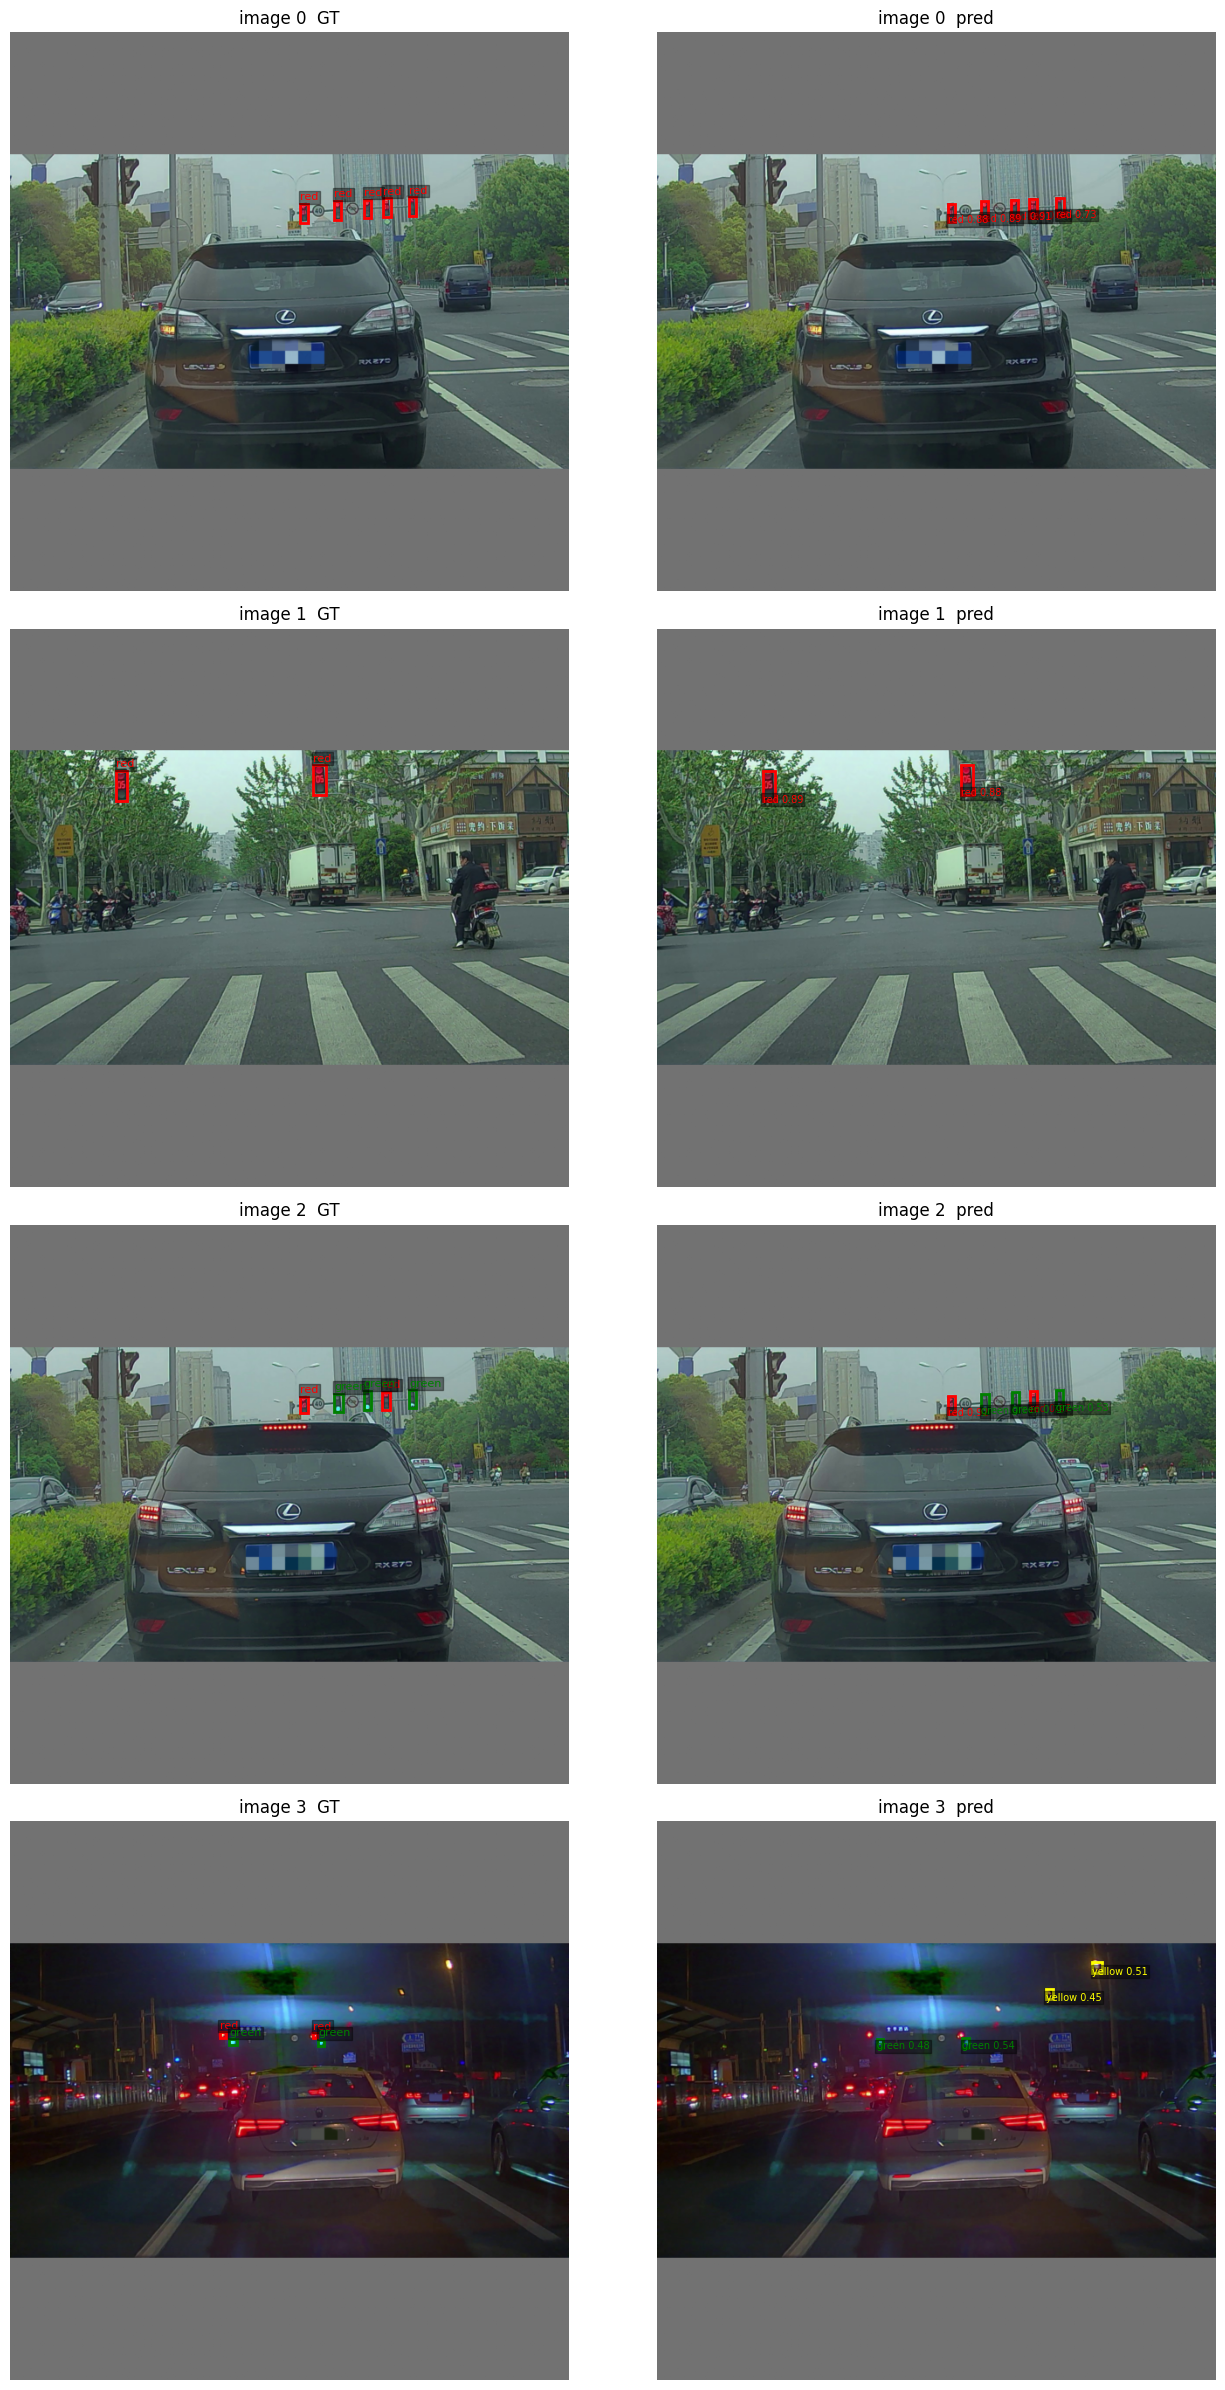

In [ ]:
# Overlay
visualize_predictions(model, test_loader, DEVICE,
                      n_images=4,
                      score_thr=S2TLD_SCORE_THR,
                      nms_iou=0.4,
                      num_classes=4,
                      class_names=S2TLD_CLASSES)


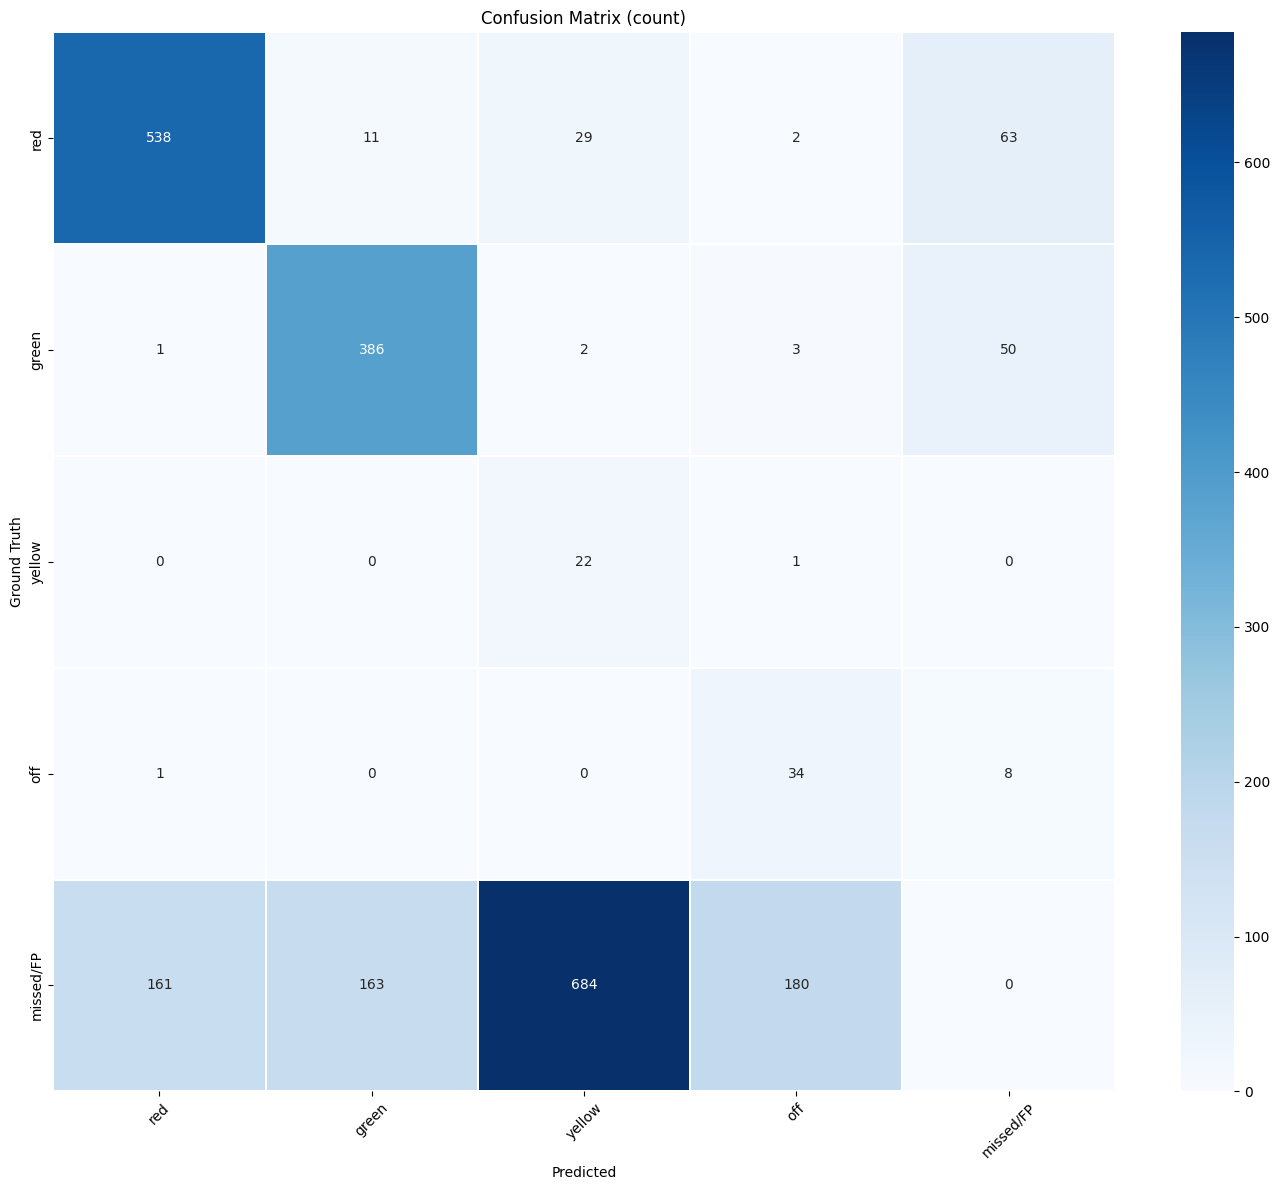

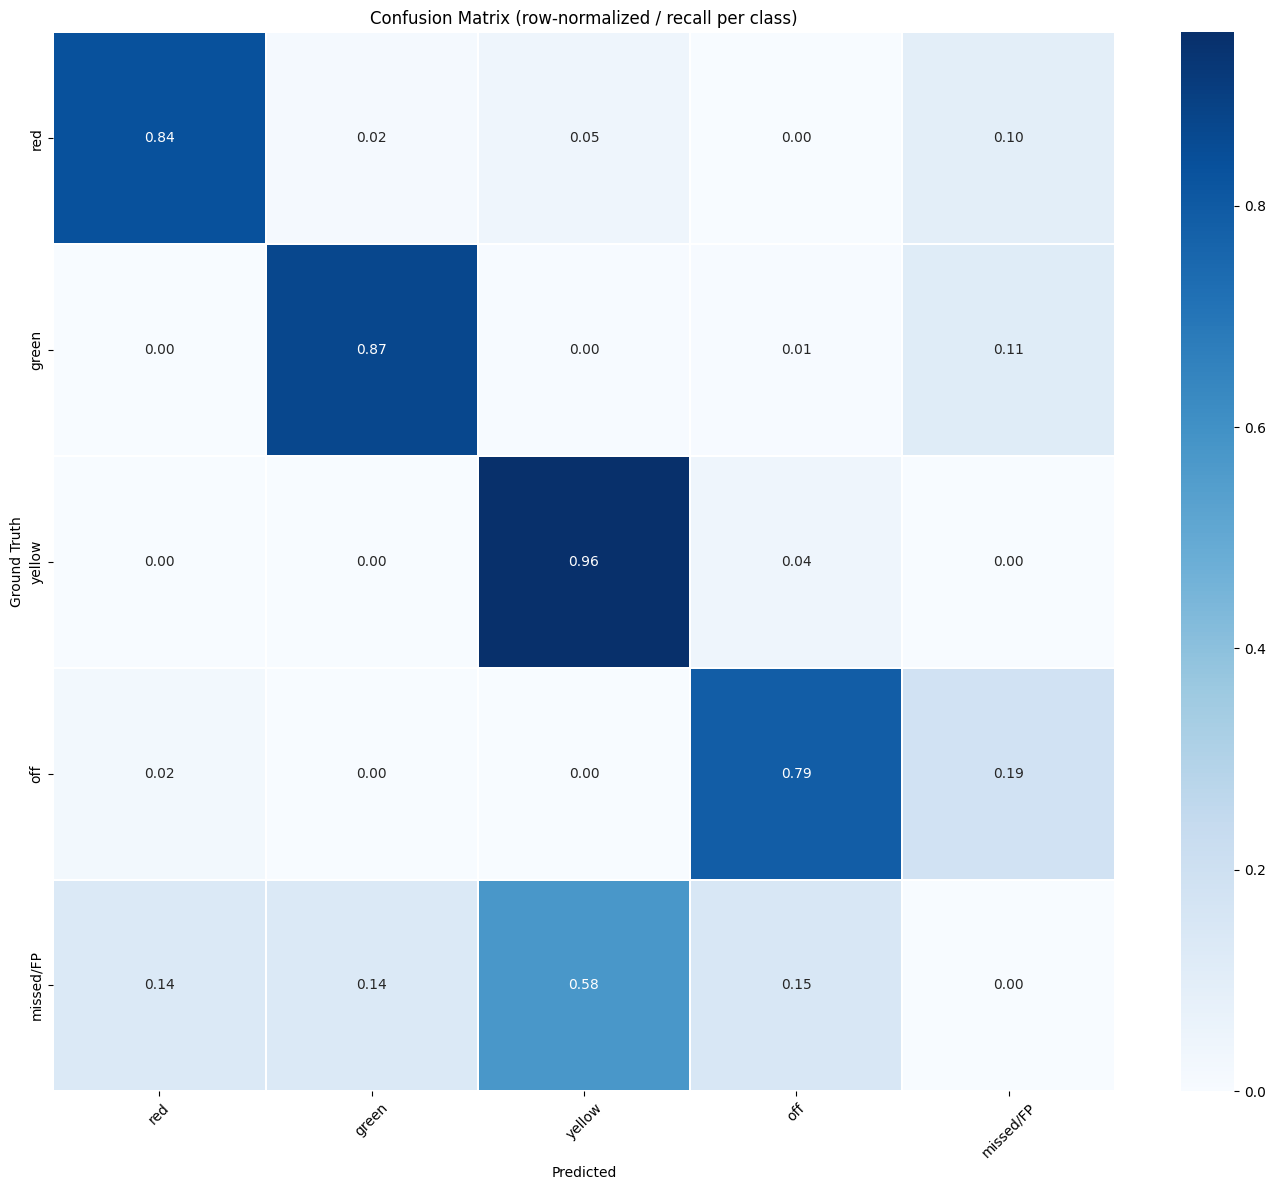

In [154]:
# Confusion Matrix
cm = compute_confusion_matrix(model, test_loader, DEVICE, num_classes=4, score_thr=0.4)
plot_confusion_matrix(cm, S2TLD_CLASSES)

In [40]:
CLASS_COLORS = {'red': 'red', 'green': 'green', 'yellow': 'gold', 'off': 'gray'}

def plot_pr_curves_from_data(all_preds, gt_counts, class_names):
    num_classes = len(class_names)
    fig, axes = plt.subplots(1, num_classes, figsize=(5 * num_classes, 4))
    if num_classes == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        name  = class_names[k]
        n_gt  = gt_counts[k]
        color = CLASS_COLORS.get(name, 'steelblue')   # ← 클래스별 색
        records = sorted(all_preds[k], key=lambda x: -x[0])

        if not records:
            ax.set_title(f"{name}  (no pred)")
            continue

        tp_arr    = np.array([r[1] for r in records])
        tp_cum    = np.cumsum(tp_arr)
        fp_cum    = np.cumsum(1 - tp_arr)
        precision = tp_cum / (tp_cum + fp_cum + 1e-8)
        recall    = tp_cum / (n_gt + 1e-8)

        ap = 0.0
        for thr in np.linspace(0, 1, 101):
            mask = recall >= thr
            ap += precision[mask].max() if mask.any() else 0.0
        ap /= 101

        ax.plot(recall, precision, color=color, linewidth=2)
        ax.fill_between(recall, precision, alpha=0.2, color=color)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f"{name}  AP={ap:.4f}  (GT={n_gt})", color=color)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Per-class Precision-Recall Curves', fontsize=13)
    plt.tight_layout()
    plt.show()

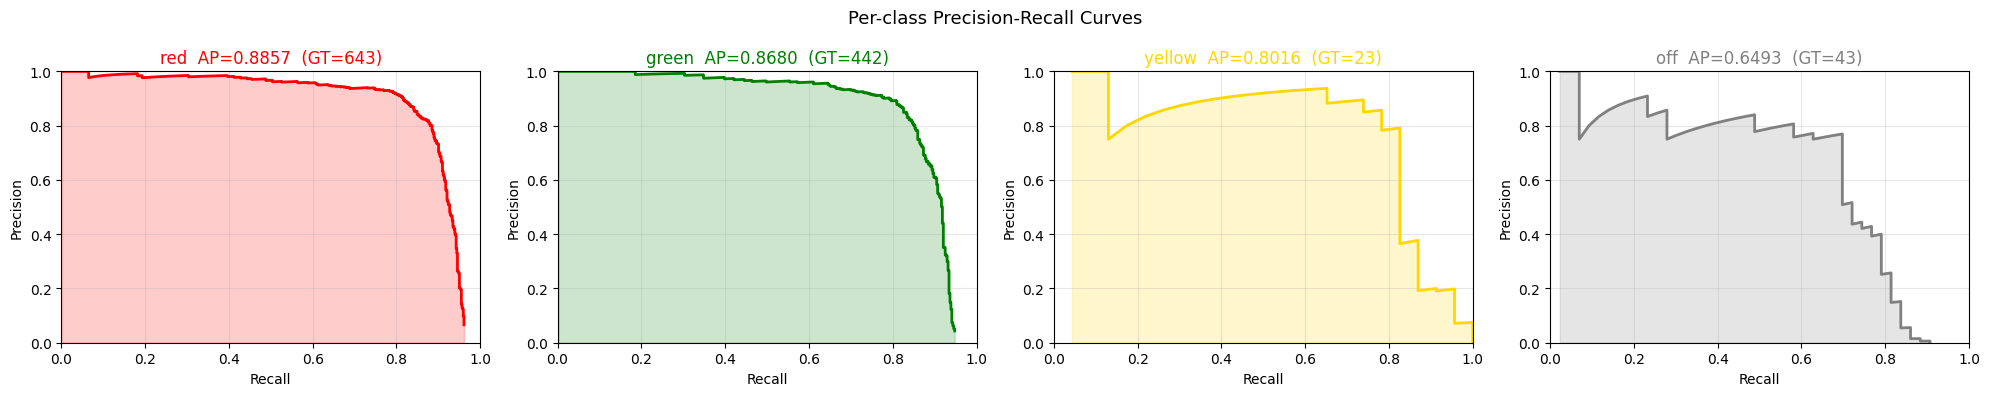

In [41]:
plot_pr_curves_from_data(all_preds, gt_counts, S2TLD_CLASSES)